# Time Series Analysis: Google Trends vs Border Encounters & Visas

**Objective**: Assess the feasibility of using Google Trends data to predict migration surges (border encounters and visa issuances).
**Key Focus**: High-volume countries (Mexico, Northern Triangle, Venezuela, Cuba).
**Methodology**:
1. Data Prep & Alignment (Monthly Cadence)
2. Cross-Correlation & Time-Lagged Analysis
3. Predictive Benchmarking (VAR modeling vs Baseline)

In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.stattools import adfuller, ccf, grangercausalitytests
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Define data paths
DATA_PROCESSED = Path('../data/processed')
DATA_RAW = Path('../data/raw')
TRENDS_DIR = DATA_RAW / 'trends'

print("Libraries imported and paths set")

Libraries imported and paths set


## 1. Data Prep & Alignment

Load Google Trends data for priority countries, align timelines to a monthly cadence, and combine with the encounter and visa datasets.

In [27]:
PRIORITY_COUNTRIES = ['Mexico', 'Honduras', 'Guatemala', 'El Salvador']
file_mapping = {
    'Mexico': 'mexico.parquet',
    'Honduras': 'honduras.parquet',
    'Guatemala': 'guatemala.parquet',
    'El Salvador': 'el_salvador.parquet'
}

# 1. Load Trends Data
trends_dfs = {}
for country, filename in file_mapping.items():
    file_path = TRENDS_DIR / filename
    if file_path.exists():
        df = pl.read_parquet(file_path).to_pandas()
        
        # Ensure we have standard date formats
        if 'time' in df.columns:
            df['date'] = pd.to_datetime(df['time'])
            df = df.drop(columns=['time'])
        elif 'date' in df.columns:
            df['date'] = pd.to_datetime(df['date'])
            
        if 'date' in df.columns:
            # Resample to monthly (average search index)
            # The trend columns might be strings representing numbers, we need to convert them
            for col in df.columns:
                if col != 'date' and df[col].dtype == 'object':
                    # Sometimes trends has '<1' which fails to_numeric, replace with 0
                    df[col] = df[col].replace('<1', '0')
                    df[col] = pd.to_numeric(df[col], errors='coerce')
            
            monthly_df = df.groupby([pd.Grouper(key='date', freq='MS')]).mean().reset_index()
            
            trends_dfs[country] = monthly_df
            print(f"Loaded {country}: {len(monthly_df)} months of trends.")
        else:
            print(f"Unexpected schema in {filename}")
    else:
        print(f"Missing file: {filename}")

if 'Mexico' in trends_dfs:
    print("\nMexico Trends Sample:")
    print(trends_dfs['Mexico'].head())

Loaded Mexico: 110 months of trends.
Loaded Honduras: 110 months of trends.
Loaded Guatemala: 110 months of trends.
Loaded El Salvador: 110 months of trends.

Mexico Trends Sample:
        date  us_asylum  us_visa  green_card  us_jobs  study_us  cbp_one  \
0 2017-02-01        0.0     21.0        21.0      2.0       0.0      0.0   
1 2017-03-01        0.0     18.0        11.0      2.0       1.0      0.0   
2 2017-04-01        0.0     17.0        13.0      3.0       1.0      0.0   
3 2017-05-01        0.0     18.0        13.0      2.0       1.0      0.0   
4 2017-06-01        0.0     24.0        13.0      2.0       1.0      0.0   

   usaid  us_passport  
0    0.0          7.0  
1    0.0          7.0  
2    0.0          7.0  
3    0.0          6.0  
4    0.0          7.0  


In [15]:
# 2. Load Encounters Data
def load_encounters():
    encounter_dir = DATA_RAW / 'encounter'
    encounter_files = list(encounter_dir.glob('*.csv'))
    
    dfs = []
    for file in sorted(encounter_files):
        df = pd.read_csv(file)
        dfs.append(df)
        
    if dfs:
        df = pd.concat(dfs, ignore_index=True).drop_duplicates()
        
        # Standardize dates
        month_map = {
            'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6,
            'JUL': 7, 'AUG': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12
        }
        df['Fiscal Year'] = pd.to_numeric(df['Fiscal Year'], errors='coerce')
        df['month_num'] = df['Month (abbv)'].map(month_map)
        
        df['calendar_year'] = df.apply(
            lambda row: int(row['Fiscal Year']) if pd.notna(row['Fiscal Year']) and row['month_num'] < 10 else (int(row['Fiscal Year']) - 1 if pd.notna(row['Fiscal Year']) else None),
            axis=1
        )
        df = df.dropna(subset=['calendar_year'])
        df['calendar_year'] = df['calendar_year'].astype(int)
        
        df['date'] = pd.to_datetime(
            df['calendar_year'].astype(str) + '-' + 
            df['month_num'].astype(str) + '-01'
        )
        
        return df
    return None

encounter_df = load_encounters()
if encounter_df is not None:
    print(f"Encounters data loaded: {len(encounter_df)} records.")

# 3. Load Visa Data
visa_parquet = DATA_PROCESSED / 'visa_master.parquet'
if visa_parquet.exists():
    visa_df = pl.read_parquet(visa_parquet).to_pandas()
    visa_df['date'] = pd.to_datetime(visa_df['date'])
    print(f"Visa data loaded: {len(visa_df)} records.")
else:
    visa_df = None
    print("Visa master not found.")

Encounters data loaded: 5784 records.
Visa data loaded: 181831 records.


In [23]:
# Combine Data per Country
country_ts_data = {}

for country in PRIORITY_COUNTRIES:
    print(f"\nProcessing {country}...")
    
    # Encounters
    enc_c = encounter_df[encounter_df['Citizenship Grouping'] == country] if encounter_df is not None else pd.DataFrame()
    if len(enc_c) > 0:
        enc_monthly = enc_c.groupby('date')['Encounter Count'].sum().reset_index()
    else:
        enc_monthly = pd.DataFrame(columns=['date', 'Encounter Count'])
        
    # Visas
    visa_c = visa_df[visa_df['country'] == country] if visa_df is not None else pd.DataFrame()
    if len(visa_c) > 0:
        visa_monthly = visa_c.groupby('date')['issuances'].sum().reset_index()
    else:
        visa_monthly = pd.DataFrame(columns=['date', 'issuances'])
        
    # Merge Encounters & Visas
    if not enc_monthly.empty and not visa_monthly.empty:
        merged = pd.merge(enc_monthly, visa_monthly, on='date', how='outer').fillna(0)
    elif not enc_monthly.empty:
        merged = enc_monthly.copy()
        merged['issuances'] = 0
    elif not visa_monthly.empty:
        merged = visa_monthly.copy()
        merged['Encounter Count'] = 0
    else:
        continue
        
    # Merge with Trends
    if country in trends_dfs:
        trends = trends_dfs[country]
        merged = pd.merge(merged, trends, on='date', how='left')
        
        # Forward fill or fillna with 0 for missing trends? 
        # For search intensity it's better to interpolate or fill 0 depending on gaps
        merged = merged.fillna(0)
        
    country_ts_data[country] = merged.sort_values('date').set_index('date')
    print(f"Final TS shaped {country_ts_data[country].shape}")
    
# Display Mexico TS
if 'Mexico' in country_ts_data:
    print("\nMexico Time Series Data (Head):")
    display(country_ts_data['Mexico'].head())


Processing Mexico...
Final TS shaped (103, 10)

Processing Honduras...
Final TS shaped (103, 10)

Processing Guatemala...
Final TS shaped (103, 10)

Processing El Salvador...
Final TS shaped (103, 10)

Mexico Time Series Data (Head):


,Encounter Count,issuances,us_asylum,us_visa,green_card,us_jobs,study_us,cbp_one,usaid,us_passport
date,,,,,,,,,,
2017-03-01,0.0,7563.0,0.0,18.0,11.0,2.0,1.0,0.0,0.0,7.0
2017-04-01,0.0,6604.0,0.0,17.0,13.0,3.0,1.0,0.0,0.0,7.0
2017-05-01,0.0,8361.0,0.0,18.0,13.0,2.0,1.0,0.0,0.0,6.0
2017-06-01,0.0,7637.0,0.0,24.0,13.0,2.0,1.0,0.0,0.0,7.0
2017-07-01,0.0,7675.0,0.0,22.0,14.0,3.0,0.0,0.0,0.0,8.0


## 2. Exploratory Time Series Analysis & Correlation

We compute Cross-Correlation Functions (CCF) to assess whether specific Google Trends keywords lead Border Encounters or Visa Issuances.

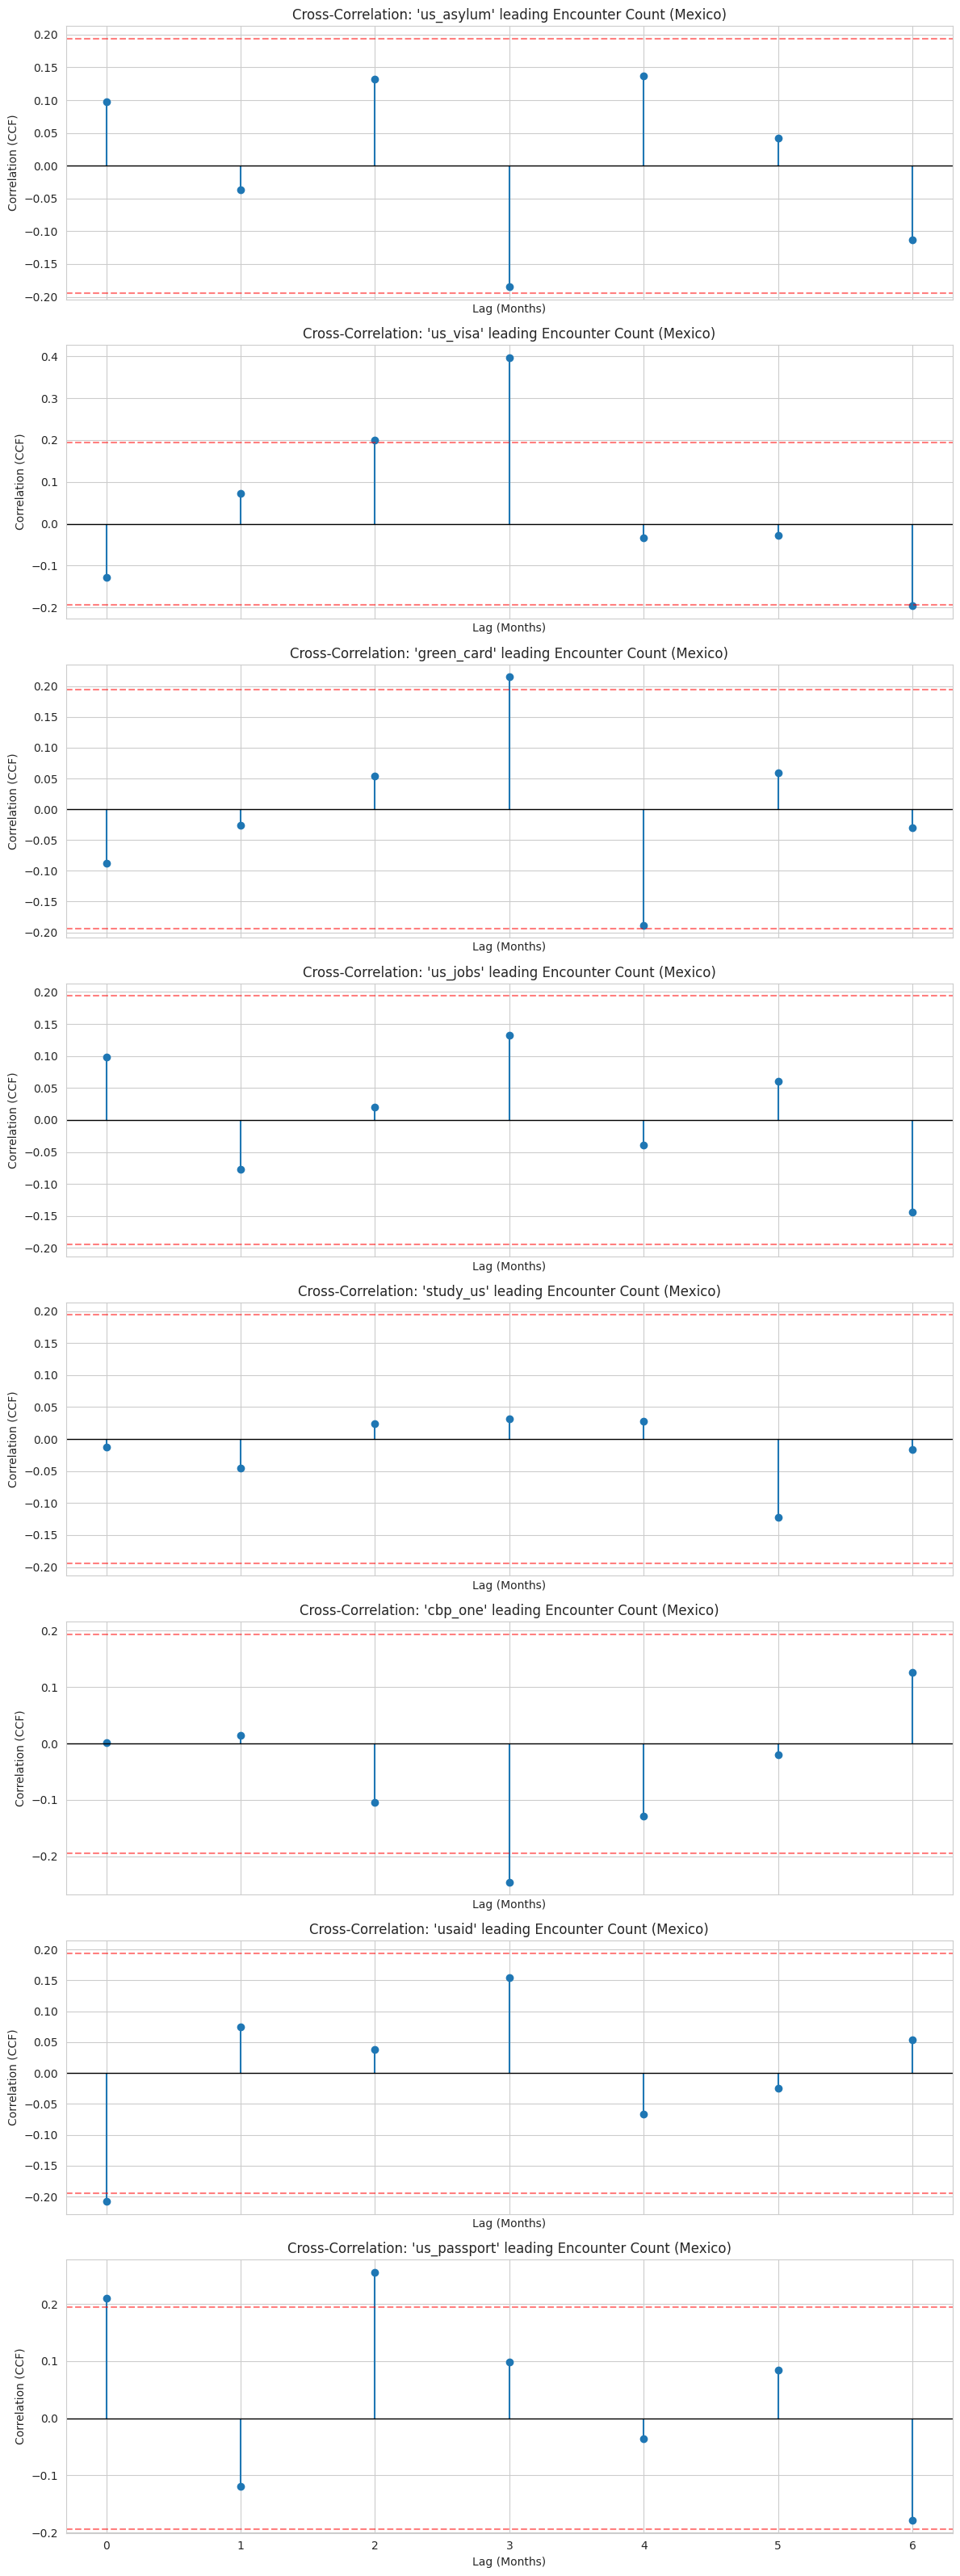

In [24]:
def plot_cross_correlation(country, target_col='Encounter Count', max_lags=6):
    if country not in country_ts_data:
        print(f"No data for {country}")
        return
        
    df = country_ts_data[country].copy()
    if len(df) < max_lags * 3:
        print(f"Not enough data for {country}")
        return
        
    # Get trend columns
    non_trend_cols = ['Encounter Count', 'issuances']
    trend_cols = [c for c in df.columns if c not in non_trend_cols]
    
    if not trend_cols:
        print(f"No Google Trends columns for {country}")
        return
        
    fig, axes = plt.subplots(nrows=len(trend_cols), ncols=1, figsize=(12, 4 * len(trend_cols)), sharex=True)
    if len(trend_cols) == 1:
        axes = [axes]
        
    for i, t_col in enumerate(trend_cols):
        # We need to ensure stationarity for valid CCF but for exploratory we'll use first differences or basic values
        # Let's use differenced series to avoid spurious correlation from non-stationarity
        y = df[target_col].diff().dropna()
        x = df[t_col].diff().dropna()
        
        # Align indices
        common_idx = x.index.intersection(y.index)
        x = x.loc[common_idx]
        y = y.loc[common_idx]
        
        if len(x) < 20: 
            axes[i].text(0.5, 0.5, 'Insufficient data after alignment', ha='center')
            continue
            
        corrs = ccf(x, y, adjusted=False) # x leads y
        corrs = corrs[:max_lags+1]
        
        axes[i].stem(range(max_lags+1), corrs, basefmt=" ")
        axes[i].axhline(0, color='black', lw=1)
        axes[i].set_title(f"Cross-Correlation: '{t_col}' leading {target_col} ({country})")
        axes[i].set_ylabel("Correlation (CCF)")
        axes[i].set_xlabel("Lag (Months)")
        
        # Add 95% confidence intervals
        conf_int = 1.96 / np.sqrt(len(x))
        axes[i].axhline(conf_int, color='red', linestyle='--', alpha=0.5)
        axes[i].axhline(-conf_int, color='red', linestyle='--', alpha=0.5)
        
    plt.tight_layout()
    plt.show()

# Run for Mexico as an example
plot_cross_correlation('Mexico', target_col='Encounter Count')

## 2.1 Side-by-Side Plots: Google Trends vs Visas & Encounters

The left panel shows Google Trends keyword time series for a country.
The right panel shows visa issuances and border encounters on synchronized time axes (dual y-axis).

This gives a quick visual check of whether trend spikes appear near migration spikes.

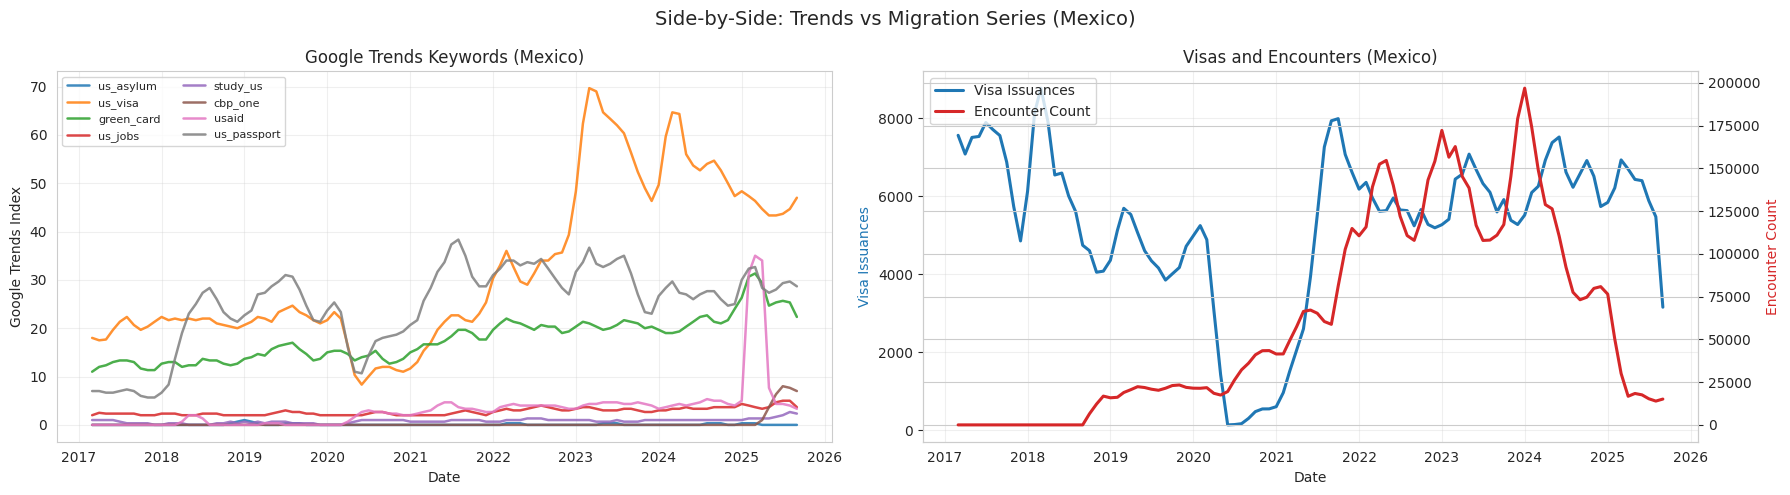

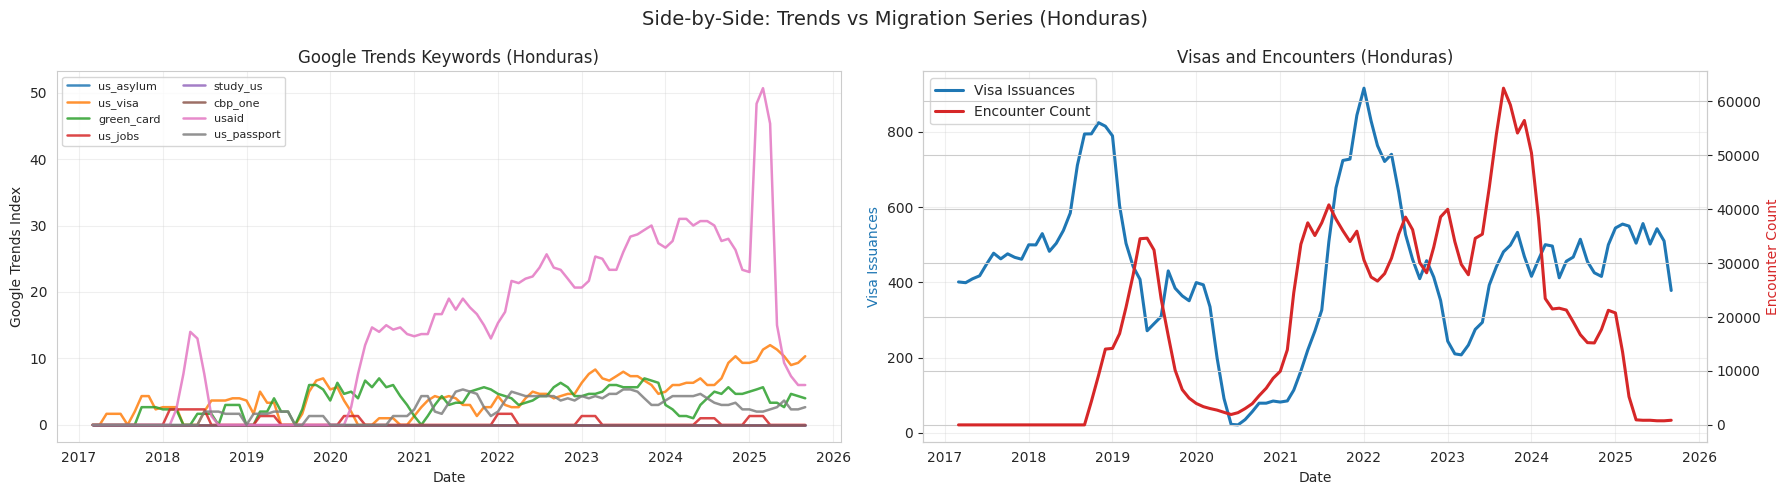

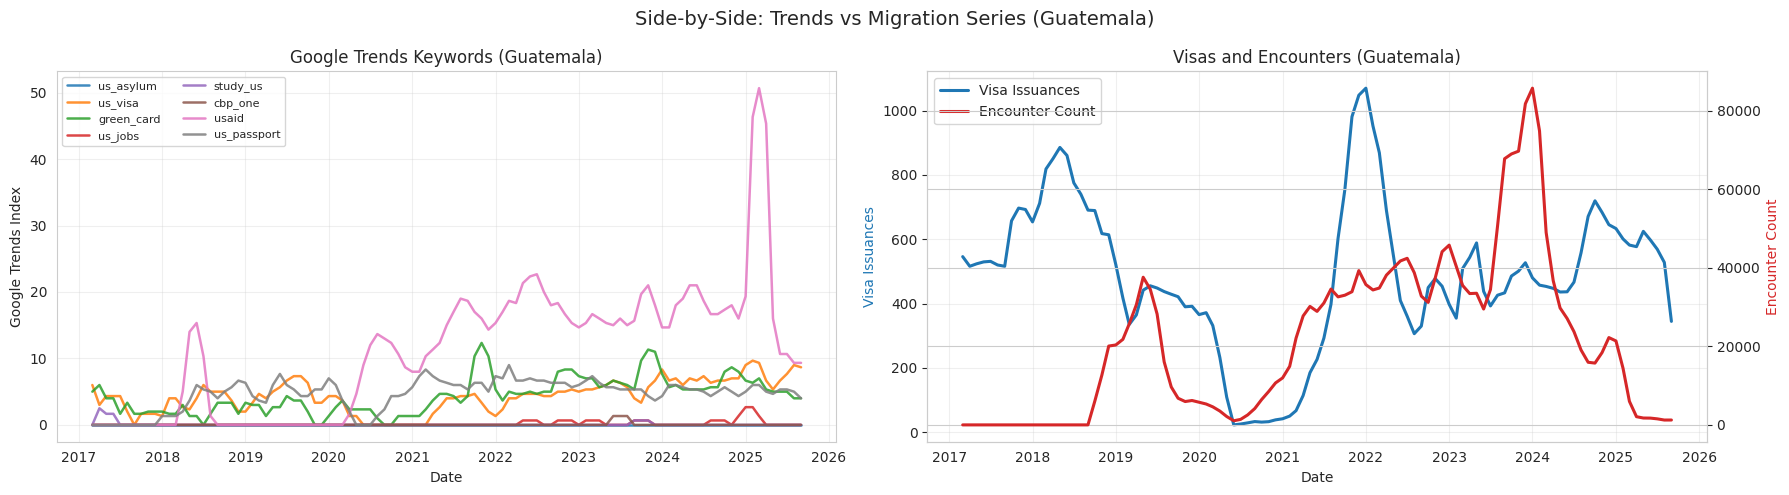

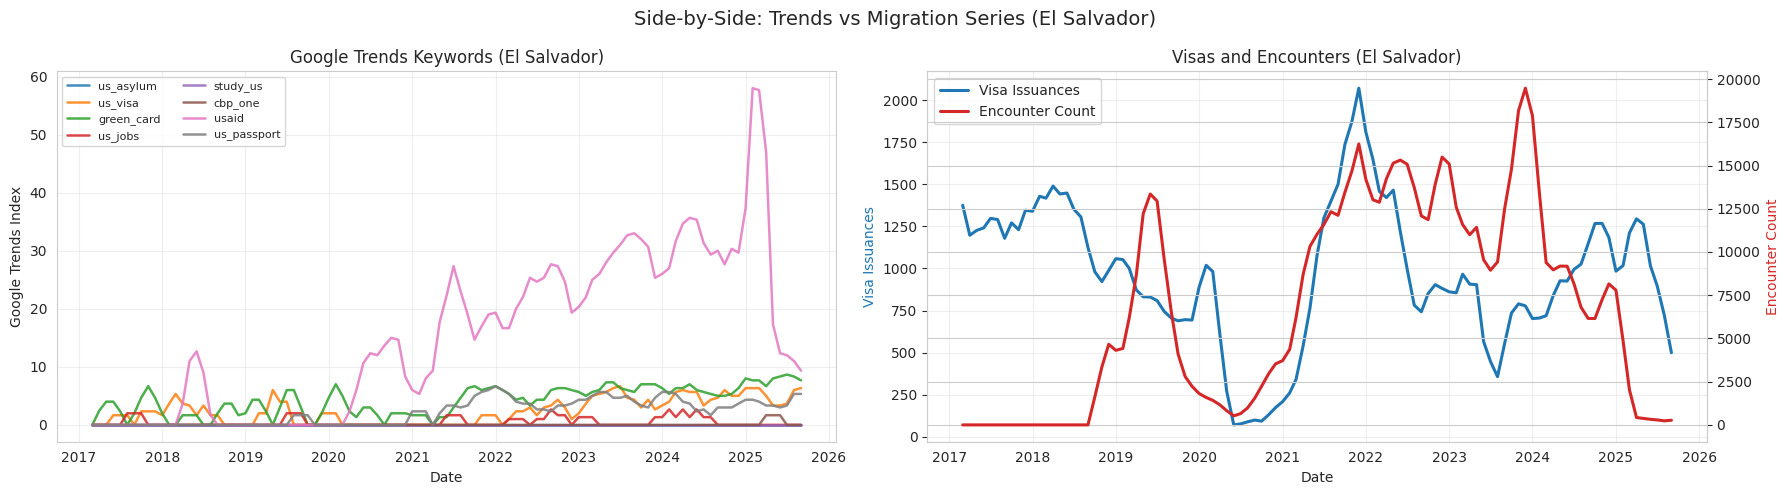

In [28]:
def plot_trends_visa_encounters_side_by_side(country, keywords=None, smooth_window=3):
    if country not in country_ts_data:
        print(f"No data available for {country}")
        return

    df = country_ts_data[country].copy().sort_index()
    trend_cols = [c for c in df.columns if c not in ['Encounter Count', 'issuances']]

    if not trend_cols:
        print(f"No Google Trends columns found for {country}")
        return

    if keywords is None:
        keywords = trend_cols
    else:
        keywords = [k for k in keywords if k in trend_cols]

    if len(keywords) == 0:
        print(f"No valid keyword columns selected for {country}")
        return

    plot_df = df.copy()
    if smooth_window and smooth_window > 1:
        for col in keywords + ['Encounter Count', 'issuances']:
            if col in plot_df.columns:
                plot_df[col] = plot_df[col].rolling(smooth_window, min_periods=1).mean()

    fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharex=True)

    # Left: Google Trends keywords
    for col in keywords:
        axes[0].plot(plot_df.index, plot_df[col], linewidth=1.8, label=col, alpha=0.85)
    axes[0].set_title(f"Google Trends Keywords ({country})")
    axes[0].set_xlabel("Date")
    axes[0].set_ylabel("Google Trends Index")
    axes[0].legend(loc='upper left', fontsize=8, ncol=2)
    axes[0].grid(True, alpha=0.3)

    # Right: Visa + Encounters (dual axis)
    ax_right = axes[1]
    ax_right_2 = ax_right.twinx()

    line1 = ax_right.plot(plot_df.index, plot_df['issuances'], color='tab:blue', linewidth=2.2, label='Visa Issuances')
    line2 = ax_right_2.plot(plot_df.index, plot_df['Encounter Count'], color='tab:red', linewidth=2.2, label='Encounter Count')

    ax_right.set_title(f"Visas and Encounters ({country})")
    ax_right.set_xlabel("Date")
    ax_right.set_ylabel("Visa Issuances", color='tab:blue')
    ax_right_2.set_ylabel("Encounter Count", color='tab:red')
    ax_right.grid(True, alpha=0.3)

    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax_right.legend(lines, labels, loc='upper left')

    fig.suptitle(f"Side-by-Side: Trends vs Migration Series ({country})", fontsize=14)
    plt.tight_layout()
    plt.show()


# Plot for each country in scope
for country_name in PRIORITY_COUNTRIES:
    plot_trends_visa_encounters_side_by_side(country_name, smooth_window=3)

## 2.2 Correlation Summary: Trends vs Visas and Encounters

This computes:
- Same-month Pearson correlation
- Best lead correlation within 0–6 months where Google Trends leads migration outcomes

A positive best-lead correlation suggests trends may be useful as early-warning indicators.

In [29]:
def _safe_corr(series_x, series_y):
    aligned = pd.concat([series_x, series_y], axis=1).dropna()
    if aligned.shape[0] < 12:
        return np.nan
    if aligned.iloc[:, 0].std() == 0 or aligned.iloc[:, 1].std() == 0:
        return np.nan
    return aligned.iloc[:, 0].corr(aligned.iloc[:, 1])


def best_lead_corr(trend_series, target_series, max_lead=6):
    """
    Lead definition: trend at time t predicts target at time t+lead.
    Returns best lead by absolute correlation.
    """
    best = {'lead_months': np.nan, 'corr': np.nan}
    best_abs = -1

    for lead in range(0, max_lead + 1):
        corr_val = _safe_corr(trend_series, target_series.shift(-lead))
        if pd.notna(corr_val) and abs(corr_val) > best_abs:
            best_abs = abs(corr_val)
            best = {'lead_months': lead, 'corr': corr_val}

    return best


rows = []
for country_name in PRIORITY_COUNTRIES:
    if country_name not in country_ts_data:
        continue

    df_country = country_ts_data[country_name].copy().sort_index()
    trend_cols = [c for c in df_country.columns if c not in ['Encounter Count', 'issuances']]

    for trend_col in trend_cols:
        trend_series = df_country[trend_col]
        visa_series = df_country['issuances']
        encounter_series = df_country['Encounter Count']

        same_corr_visa = _safe_corr(trend_series, visa_series)
        same_corr_enc = _safe_corr(trend_series, encounter_series)

        visa_best = best_lead_corr(trend_series, visa_series, max_lead=6)
        enc_best = best_lead_corr(trend_series, encounter_series, max_lead=6)

        rows.append({
            'country': country_name,
            'keyword': trend_col,
            'same_month_corr_visa': same_corr_visa,
            'best_lead_months_visa': visa_best['lead_months'],
            'best_lead_corr_visa': visa_best['corr'],
            'same_month_corr_encounter': same_corr_enc,
            'best_lead_months_encounter': enc_best['lead_months'],
            'best_lead_corr_encounter': enc_best['corr']
        })

corr_summary = pd.DataFrame(rows)

if corr_summary.empty:
    print("No correlation results available.")
else:
    corr_summary = corr_summary.sort_values(
        by='best_lead_corr_encounter', key=lambda s: s.abs(), ascending=False
    )

    print("Top keyword relationships by |best lead correlation| with encounters:")
    display(corr_summary.head(20).round(3))

    print("\nCountry-level strongest encounter-leading keyword:")
    top_by_country = corr_summary.loc[
        corr_summary.groupby('country')['best_lead_corr_encounter'].apply(lambda s: s.abs().idxmax())
    ].sort_values(by='best_lead_corr_encounter', key=lambda s: s.abs(), ascending=False)
    display(top_by_country[['country', 'keyword', 'best_lead_months_encounter', 'best_lead_corr_encounter']].round(3))

Top keyword relationships by |best lead correlation| with encounters:


,country,keyword,same_month_corr_visa,best_lead_months_visa,best_lead_corr_visa,same_month_corr_encounter,best_lead_months_encounter,best_lead_corr_encounter
1,Mexico,us_visa,0.401,2.0,0.427,0.614,0.0,0.614
7,Mexico,us_passport,0.128,2.0,0.144,0.538,6.0,0.591
15,Honduras,us_passport,0.035,2.0,0.224,0.521,2.0,0.591
18,Guatemala,green_card,0.210,1.0,0.270,0.389,1.0,0.487
31,El Salvador,us_passport,0.129,4.0,0.167,0.484,0.0,0.484
2,Mexico,green_card,0.240,1.0,0.245,0.454,0.0,0.454
21,Guatemala,cbp_one,-0.043,0.0,-0.043,0.007,6.0,0.421
23,Guatemala,us_passport,0.050,5.0,-0.079,0.358,6.0,0.411
30,El Salvador,usaid,0.006,2.0,0.070,0.401,0.0,0.401
14,Honduras,usaid,0.005,6.0,0.153,0.391,0.0,0.391



Country-level strongest encounter-leading keyword:


,country,keyword,best_lead_months_encounter,best_lead_corr_encounter
1,Mexico,us_visa,0.0,0.614
15,Honduras,us_passport,2.0,0.591
18,Guatemala,green_card,1.0,0.487
31,El Salvador,us_passport,0.0,0.484


## 2.3 Comparable-Scale Plot (0–100)

Google Trends is already on a bounded index-like scale, while visas and encounters are absolute counts.
To compare shape/timing directly, this cell scales visas and encounters (and optionally trend keywords) to 0–100 per country.

Note: this is for visual comparability only, not a replacement for count-based modeling.

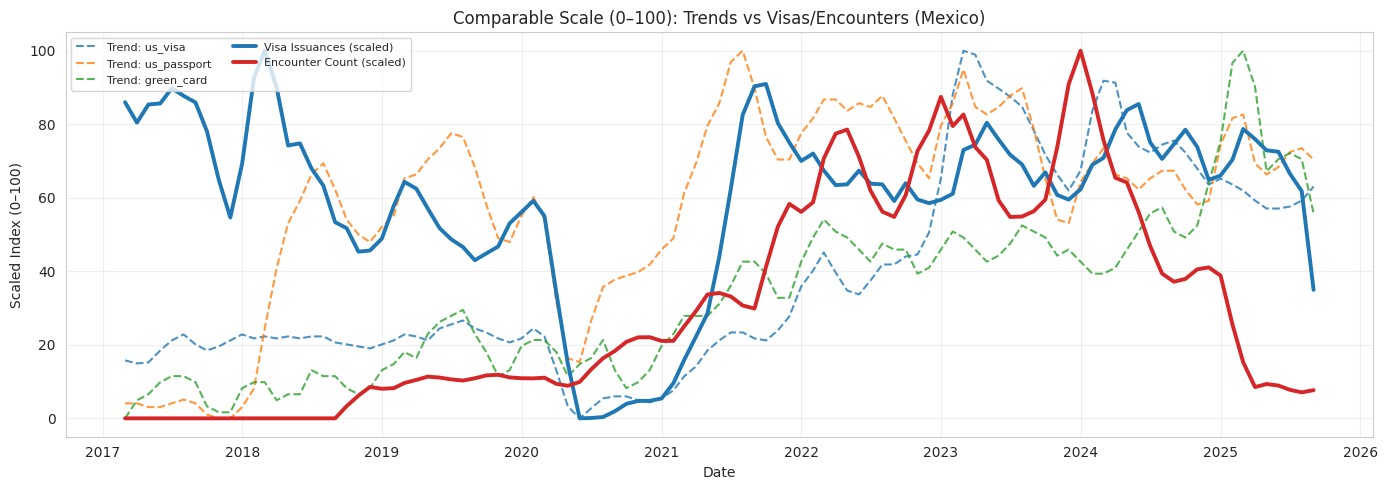

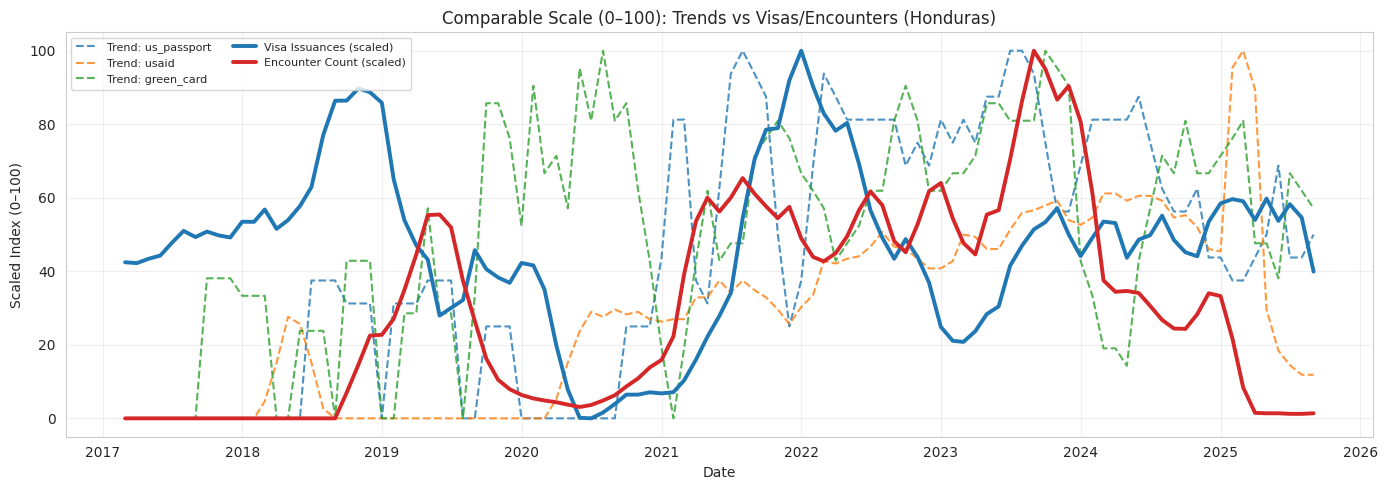

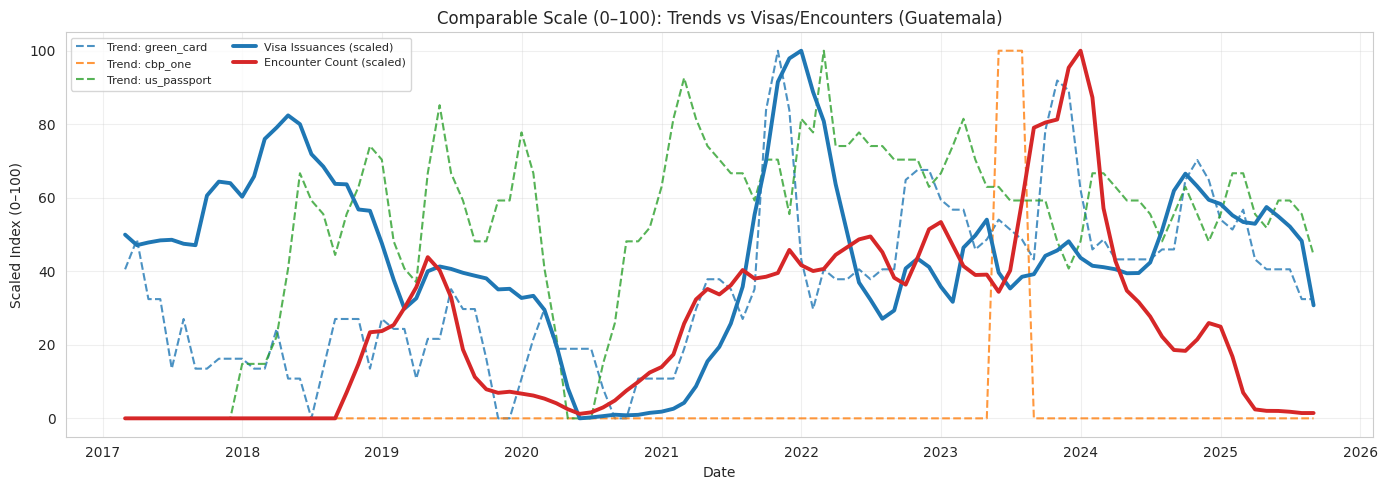

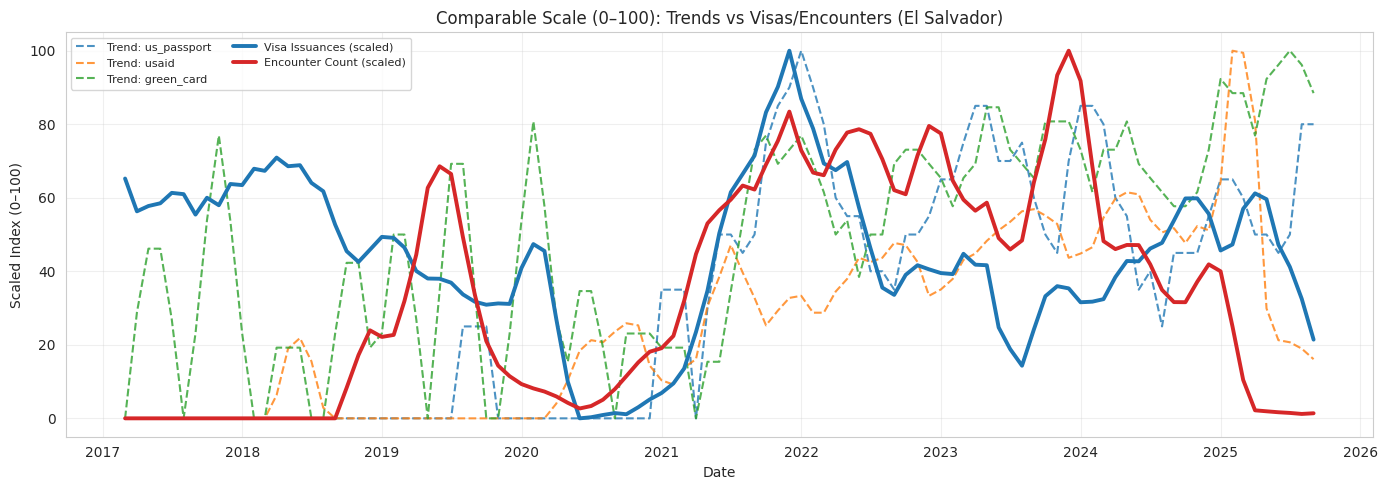

In [30]:
def _minmax_0_100(series):
    s = series.astype(float)
    s_min, s_max = s.min(), s.max()
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(np.nan, index=s.index)
    return (s - s_min) / (s_max - s_min) * 100


def plot_comparable_scale(country, top_k_keywords=3, smooth_window=3):
    if country not in country_ts_data:
        print(f"No data for {country}")
        return

    df = country_ts_data[country].copy().sort_index()
    trend_cols = [c for c in df.columns if c not in ['Encounter Count', 'issuances']]
    if not trend_cols:
        print(f"No trend columns for {country}")
        return

    # Use strongest keywords from correlation summary when available
    selected_keywords = trend_cols
    if 'corr_summary' in globals() and isinstance(corr_summary, pd.DataFrame) and not corr_summary.empty:
        country_corr = corr_summary[corr_summary['country'] == country].copy()
        if not country_corr.empty:
            country_corr = country_corr.sort_values(
                by='best_lead_corr_encounter', key=lambda s: s.abs(), ascending=False
            )
            selected_keywords = country_corr['keyword'].head(top_k_keywords).tolist()

    plot_df = df[['issuances', 'Encounter Count'] + selected_keywords].copy()

    if smooth_window and smooth_window > 1:
        plot_df = plot_df.rolling(smooth_window, min_periods=1).mean()

    scaled_df = pd.DataFrame(index=plot_df.index)
    for col in plot_df.columns:
        scaled_df[col] = _minmax_0_100(plot_df[col])

    fig, ax = plt.subplots(figsize=(14, 5))

    for kw in selected_keywords:
        ax.plot(scaled_df.index, scaled_df[kw], linewidth=1.5, alpha=0.8, linestyle='--', label=f"Trend: {kw}")

    ax.plot(scaled_df.index, scaled_df['issuances'], color='tab:blue', linewidth=2.8, label='Visa Issuances (scaled)')
    ax.plot(scaled_df.index, scaled_df['Encounter Count'], color='tab:red', linewidth=2.8, label='Encounter Count (scaled)')

    ax.set_title(f"Comparable Scale (0–100): Trends vs Visas/Encounters ({country})")
    ax.set_xlabel('Date')
    ax.set_ylabel('Scaled Index (0–100)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


for country_name in PRIORITY_COUNTRIES:
    plot_comparable_scale(country_name, top_k_keywords=3, smooth_window=3)

## 2.35 Cleaner Tracking View (Small Multiples)

To reduce clutter, this view shows only the top few keywords per country and uses one keyword per panel:
- Left panel: keyword vs encounters (both scaled 0–100)
- Right panel: keyword vs visas (both scaled 0–100)

This makes it easier to judge whether each trend series tracks timing and direction of migration outcomes.

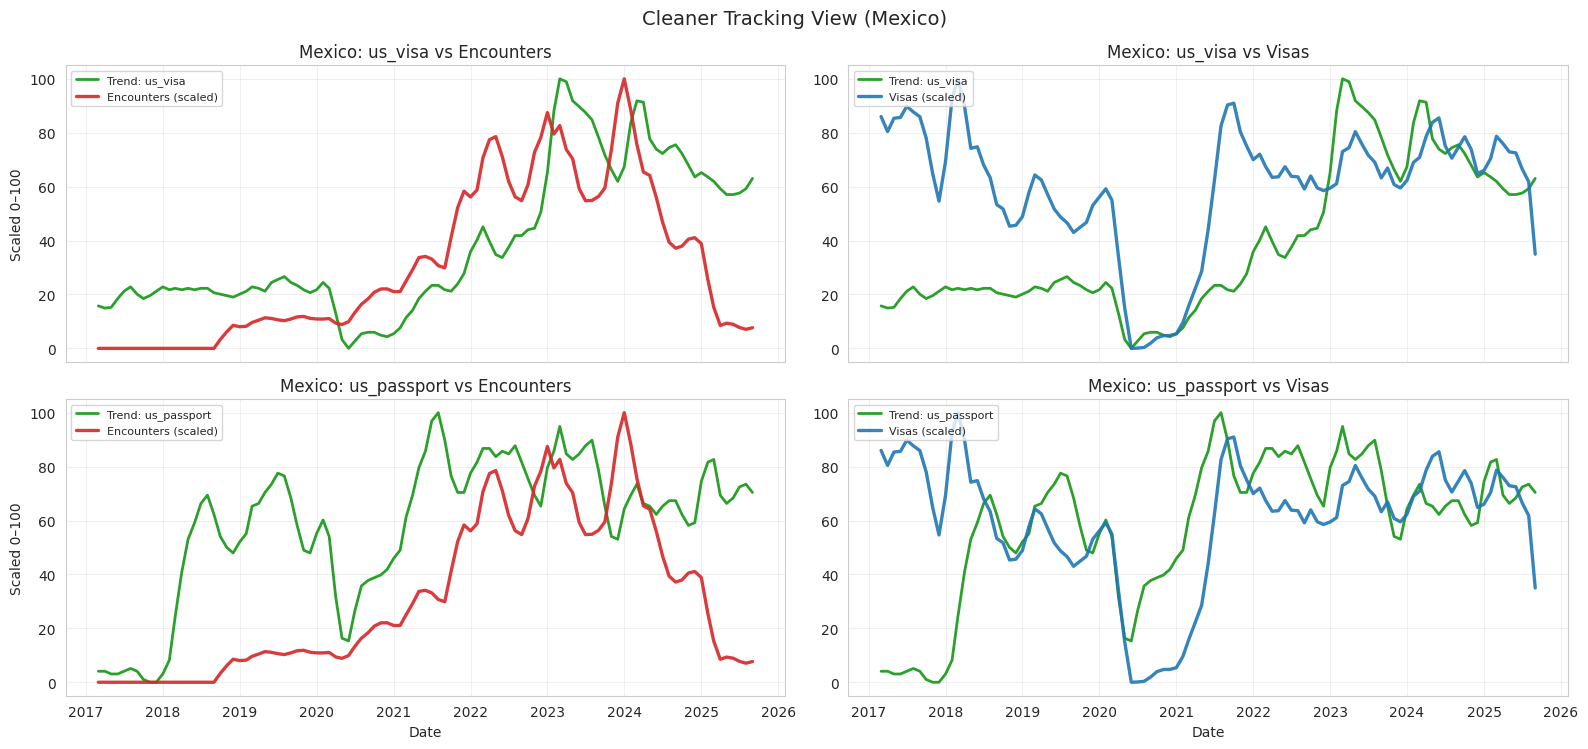

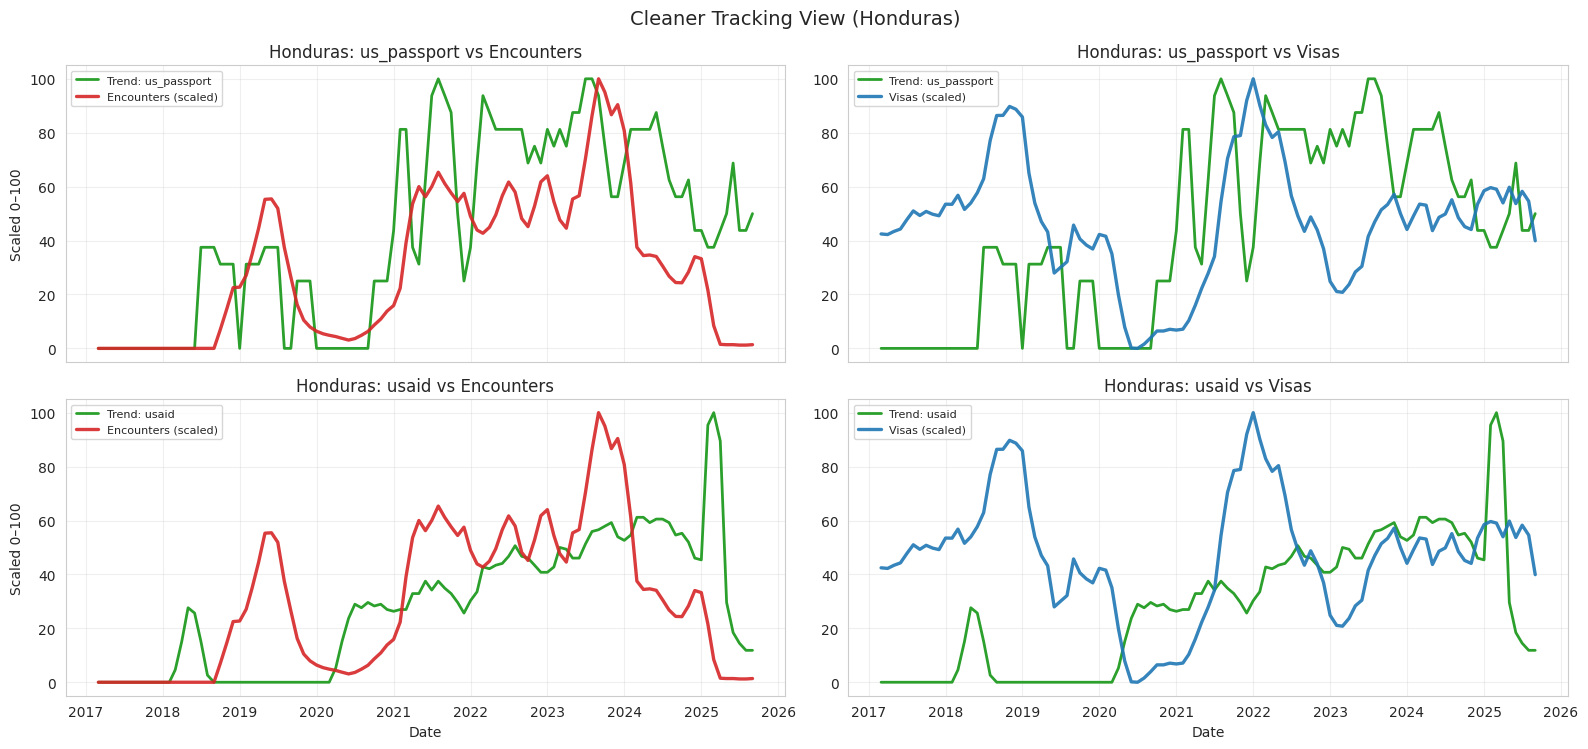

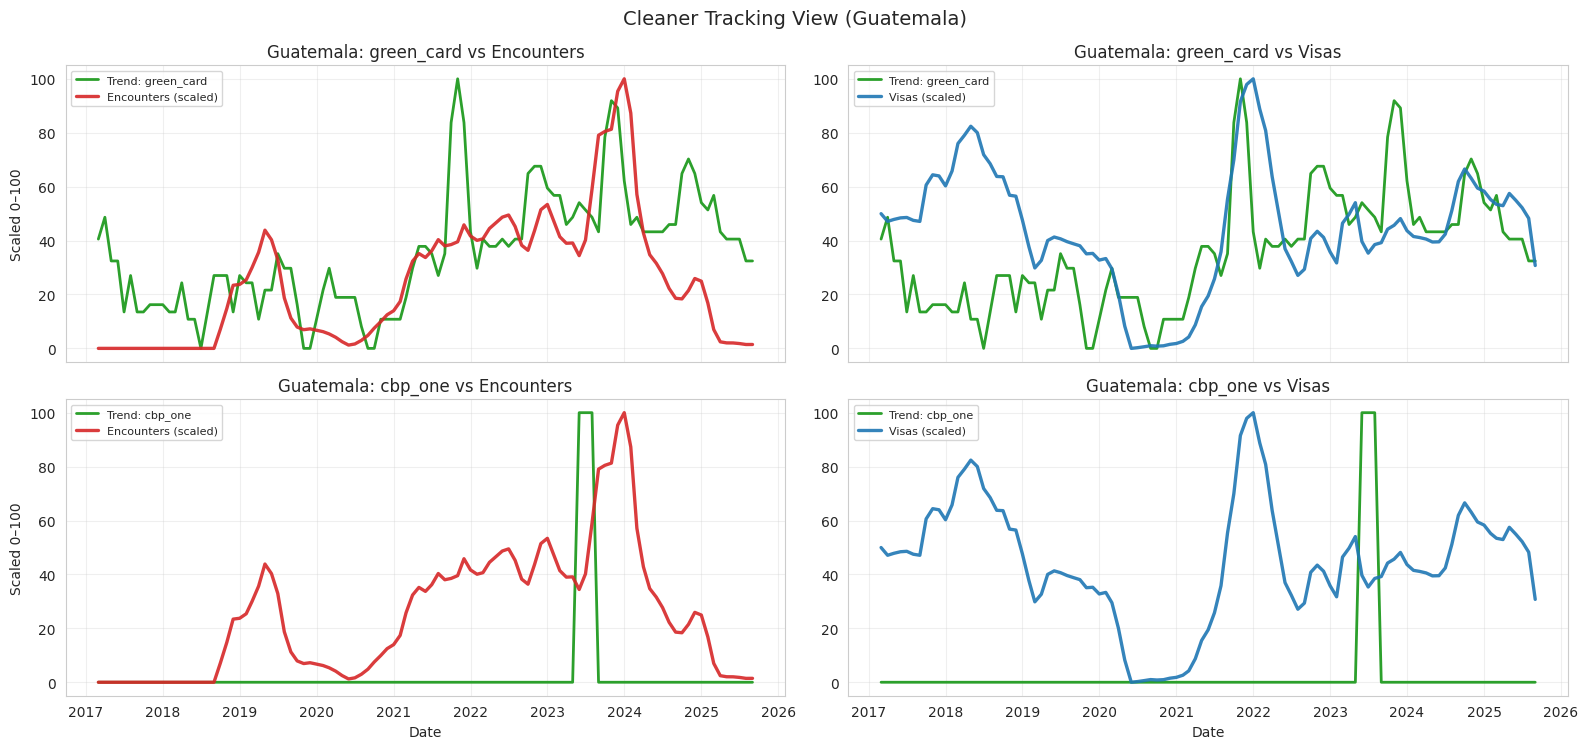

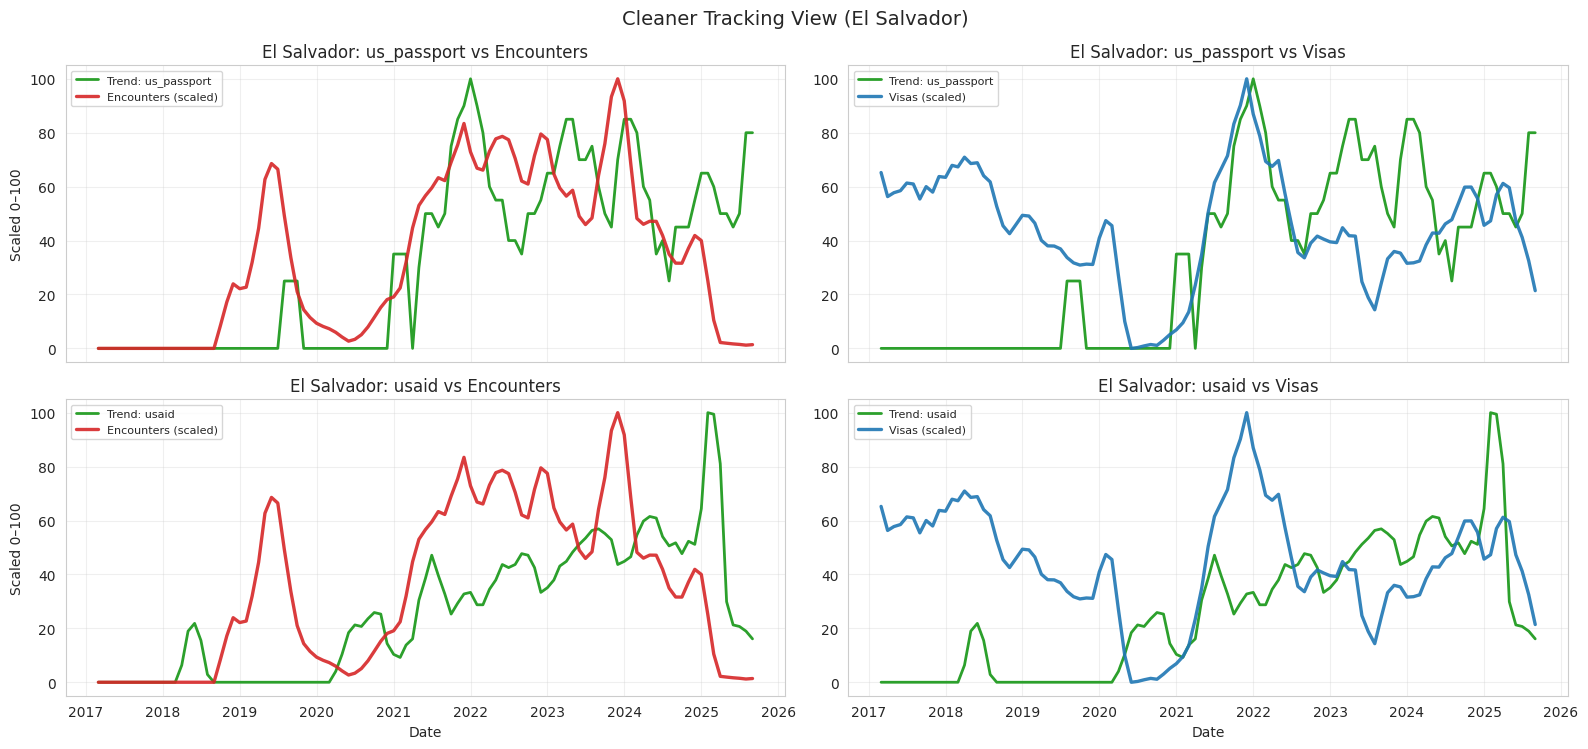

In [32]:
def _select_top_keywords_for_country(country, top_k=2):
    df = country_ts_data[country]
    trend_cols = [c for c in df.columns if c not in ['Encounter Count', 'issuances']]

    if 'corr_summary' in globals() and isinstance(corr_summary, pd.DataFrame) and not corr_summary.empty:
        subset = corr_summary[corr_summary['country'] == country].copy()
        if not subset.empty:
            subset['score'] = subset[['best_lead_corr_encounter', 'best_lead_corr_visa']].abs().max(axis=1)
            subset = subset.sort_values('score', ascending=False)
            selected = subset['keyword'].drop_duplicates().head(top_k).tolist()
            if selected:
                return selected

    return trend_cols[:top_k]


def plot_clean_tracking(country, top_k_keywords=2, smooth_window=3):
    if country not in country_ts_data:
        print(f"No data for {country}")
        return

    df = country_ts_data[country].copy().sort_index()
    selected_keywords = _select_top_keywords_for_country(country, top_k=top_k_keywords)

    if not selected_keywords:
        print(f"No trend keywords available for {country}")
        return

    base = df[['Encounter Count', 'issuances'] + selected_keywords].copy()
    if smooth_window and smooth_window > 1:
        base = base.rolling(smooth_window, min_periods=1).mean()

    scaled = pd.DataFrame(index=base.index)
    for col in base.columns:
        scaled[col] = _minmax_0_100(base[col])

    fig, axes = plt.subplots(len(selected_keywords), 2, figsize=(16, 3.8 * len(selected_keywords)), sharex=True)
    if len(selected_keywords) == 1:
        axes = np.array([axes])

    for row_idx, kw in enumerate(selected_keywords):
        # Keyword vs Encounter
        ax1 = axes[row_idx, 0]
        ax1.plot(scaled.index, scaled[kw], color='tab:green', linewidth=2, label=f'Trend: {kw}')
        ax1.plot(scaled.index, scaled['Encounter Count'], color='tab:red', linewidth=2.4, alpha=0.9, label='Encounters (scaled)')
        ax1.set_title(f"{country}: {kw} vs Encounters")
        ax1.set_ylabel('Scaled 0–100')
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc='upper left', fontsize=8)

        # Keyword vs Visa
        ax2 = axes[row_idx, 1]
        ax2.plot(scaled.index, scaled[kw], color='tab:green', linewidth=2, label=f'Trend: {kw}')
        ax2.plot(scaled.index, scaled['issuances'], color='tab:blue', linewidth=2.4, alpha=0.9, label='Visas (scaled)')
        ax2.set_title(f"{country}: {kw} vs Visas")
        ax2.grid(True, alpha=0.3)
        ax2.legend(loc='upper left', fontsize=8)

    for ax in axes[-1, :]:
        ax.set_xlabel('Date')

    fig.suptitle(f"Cleaner Tracking View ({country})", fontsize=14)
    plt.tight_layout()
    plt.show()


for country_name in PRIORITY_COUNTRIES:
    plot_clean_tracking(country_name, top_k_keywords=2, smooth_window=3)

## 2.36 Cleanest Comparison: Composite Trend Index vs Outcomes

This view reduces noise by:
- selecting top keywords per country,
- converting each keyword to a comparable 0–100 scale,
- averaging them into one composite trend index,
- applying smoothing.

You get only two panels per country: composite vs encounters, and composite vs visas.

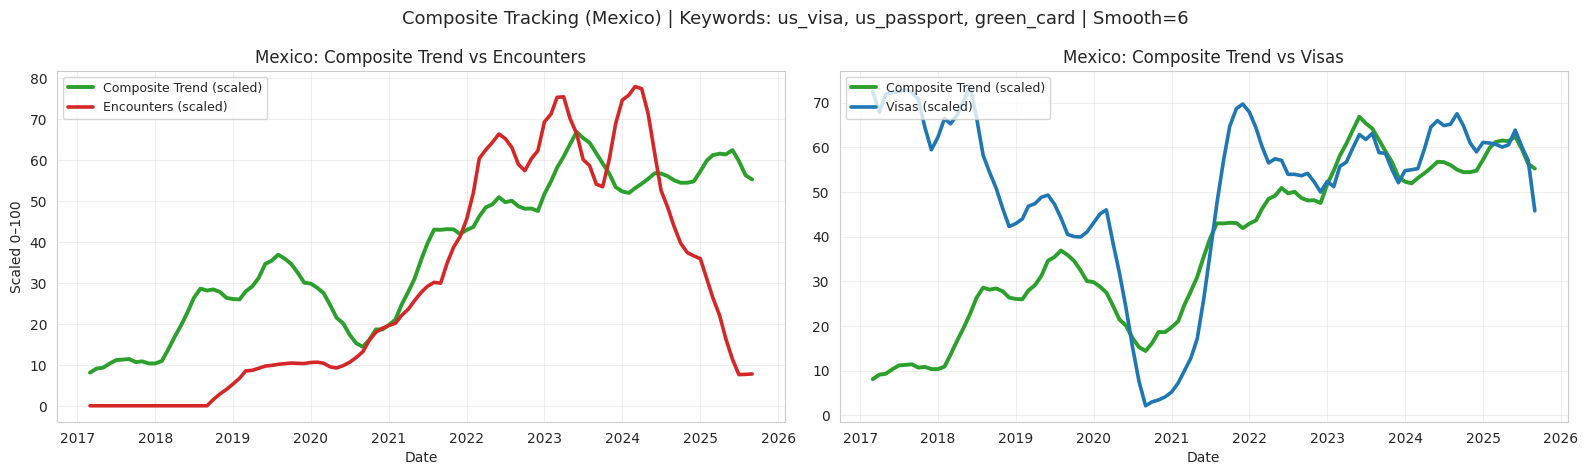

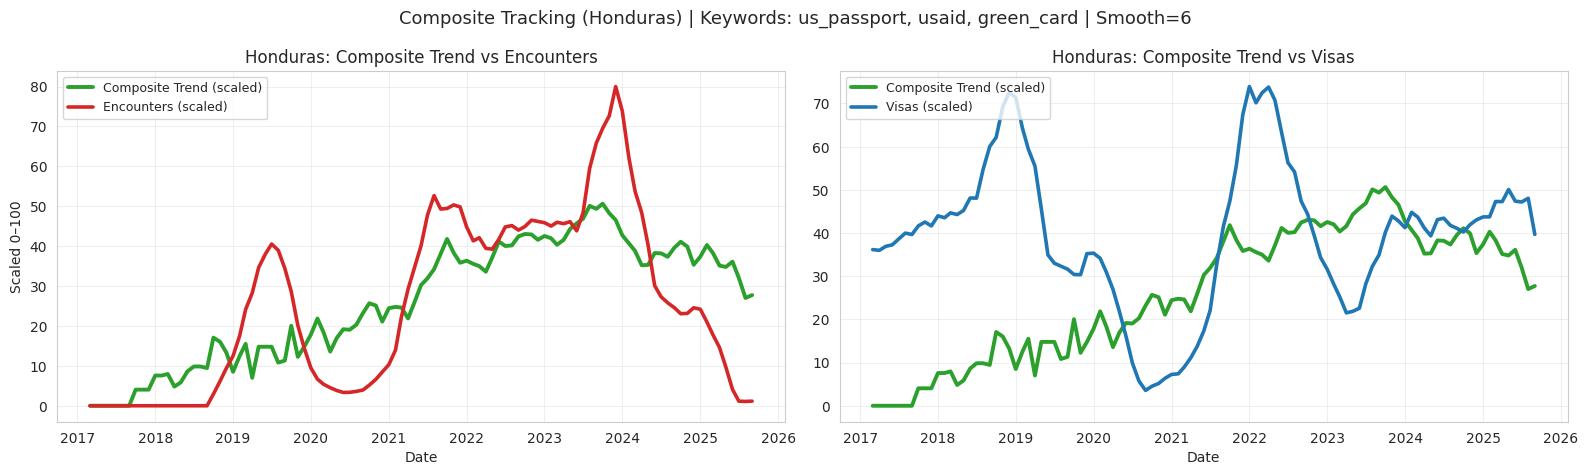

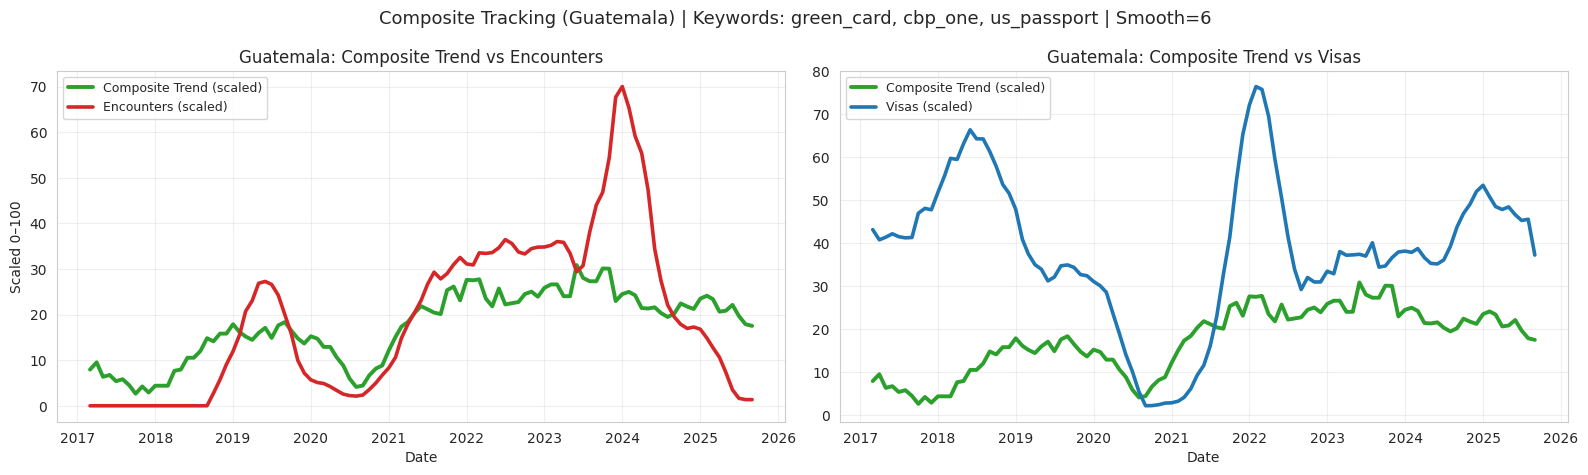

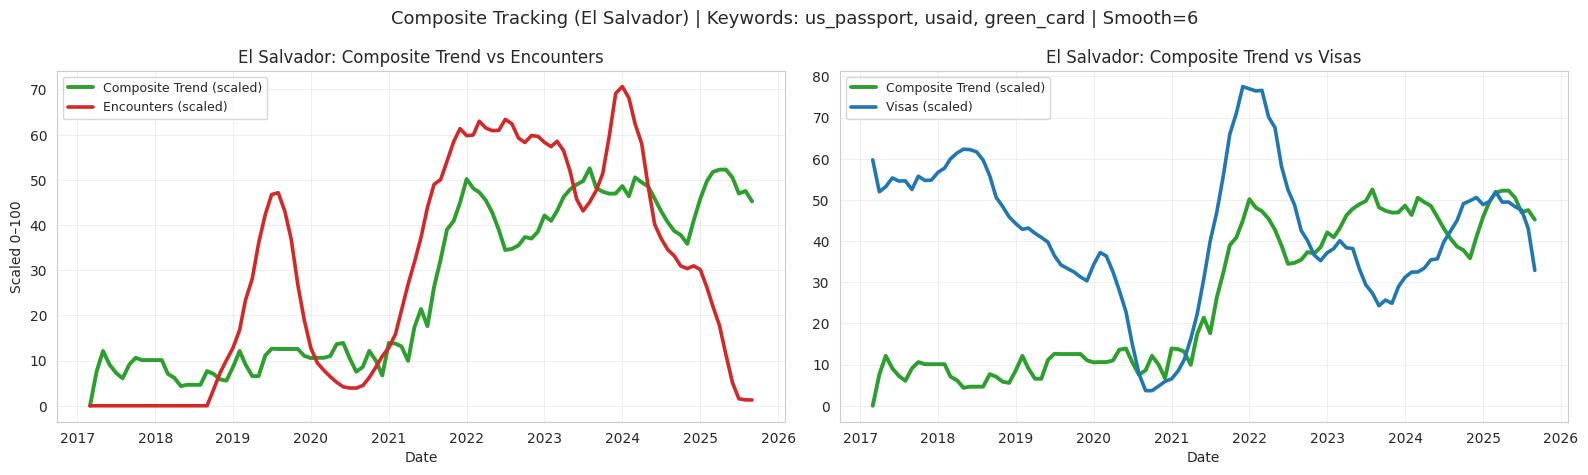

In [33]:
def plot_composite_tracking(country, top_k_keywords=3, smooth_window=6):
    if country not in country_ts_data:
        print(f"No data for {country}")
        return

    df = country_ts_data[country].copy().sort_index()
    selected_keywords = _select_top_keywords_for_country(country, top_k=top_k_keywords)
    if not selected_keywords:
        print(f"No keyword selection available for {country}")
        return

    work = df[['Encounter Count', 'issuances'] + selected_keywords].copy()

    # Scale each keyword before averaging so one keyword doesn't dominate by range
    keyword_scaled = pd.DataFrame(index=work.index)
    for kw in selected_keywords:
        keyword_scaled[kw] = _minmax_0_100(work[kw])

    work['composite_trend'] = keyword_scaled.mean(axis=1)

    # Scale outcomes for visual comparability
    work['enc_scaled'] = _minmax_0_100(work['Encounter Count'])
    work['visa_scaled'] = _minmax_0_100(work['issuances'])

    if smooth_window and smooth_window > 1:
        for col in ['composite_trend', 'enc_scaled', 'visa_scaled']:
            work[col] = work[col].rolling(smooth_window, min_periods=1).mean()

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.8), sharex=True)

    axes[0].plot(work.index, work['composite_trend'], color='tab:green', linewidth=2.8, label='Composite Trend (scaled)')
    axes[0].plot(work.index, work['enc_scaled'], color='tab:red', linewidth=2.6, label='Encounters (scaled)')
    axes[0].set_title(f"{country}: Composite Trend vs Encounters")
    axes[0].set_ylabel('Scaled 0–100')
    axes[0].set_xlabel('Date')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='upper left', fontsize=9)

    axes[1].plot(work.index, work['composite_trend'], color='tab:green', linewidth=2.8, label='Composite Trend (scaled)')
    axes[1].plot(work.index, work['visa_scaled'], color='tab:blue', linewidth=2.6, label='Visas (scaled)')
    axes[1].set_title(f"{country}: Composite Trend vs Visas")
    axes[1].set_xlabel('Date')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='upper left', fontsize=9)

    fig.suptitle(
        f"Composite Tracking ({country}) | Keywords: {', '.join(selected_keywords)} | Smooth={smooth_window}",
        fontsize=13
    )
    plt.tight_layout()
    plt.show()


for country_name in PRIORITY_COUNTRIES:
    plot_composite_tracking(country_name, top_k_keywords=3, smooth_window=6)

## 2.4 Does Normalization Improve Feasibility? (Raw VAR vs Standardized VAR)

- Correlation metrics in Section 2.2 are scale-invariant (so normalization does not change Pearson values).
- VAR estimation can be numerically sensitive to very different feature magnitudes.

This cell compares three forecast setups for encounters:
1. Baseline AutoReg on encounters only
2. Raw-scale VAR (encounters + trends)
3. Standardized VAR (z-score by train set, then inverse-transform predictions)

If standardized VAR materially lowers RMSE vs raw VAR, scaling helps model stability/fit.

In [31]:
def evaluate_scaling_impact(country, target_col='Encounter Count', test_periods=6, maxlags=1):
    if country not in country_ts_data:
        return None

    df = country_ts_data[country].copy().sort_index()
    keep_cols = [target_col] + [c for c in df.columns if c not in ['Encounter Count', 'issuances']]
    df = df[keep_cols].dropna().copy()

    # remove constant columns
    df = df.loc[:, df.std() > 0]
    if target_col not in df.columns or df.shape[0] < (test_periods + 24) or df.shape[1] < 2:
        return None

    train = df.iloc[:-test_periods].copy()
    test = df.iloc[-test_periods:].copy()

    # 1) Baseline AutoReg
    try:
        from statsmodels.tsa.ar_model import AutoReg
        base_model = AutoReg(train[target_col], lags=maxlags)
        base_fit = base_model.fit()
        pred_base = base_fit.forecast(steps=test_periods).values
        rmse_base = np.sqrt(mean_squared_error(test[target_col].values, pred_base))
    except Exception:
        rmse_base = np.nan

    # 2) Raw VAR
    try:
        raw_var = VAR(train)
        raw_fit = raw_var.fit(maxlags=maxlags)
        raw_fc = raw_fit.forecast(train.values[-raw_fit.k_ar:], steps=test_periods)
        t_idx = list(train.columns).index(target_col)
        pred_raw_var = raw_fc[:, t_idx]
        rmse_raw_var = np.sqrt(mean_squared_error(test[target_col].values, pred_raw_var))
    except Exception:
        rmse_raw_var = np.nan

    # 3) Standardized VAR (z-score using training moments only)
    try:
        mu = train.mean()
        sigma = train.std().replace(0, 1)

        train_z = (train - mu) / sigma
        std_var = VAR(train_z)
        std_fit = std_var.fit(maxlags=maxlags)

        std_fc = std_fit.forecast(train_z.values[-std_fit.k_ar:], steps=test_periods)
        t_idx = list(train.columns).index(target_col)
        pred_z_target = std_fc[:, t_idx]

        pred_std_var = pred_z_target * sigma[target_col] + mu[target_col]
        rmse_std_var = np.sqrt(mean_squared_error(test[target_col].values, pred_std_var))
    except Exception:
        rmse_std_var = np.nan

    return {
        'Country': country,
        'Baseline_AR_RMSE': rmse_base,
        'Raw_VAR_RMSE': rmse_raw_var,
        'Std_VAR_RMSE': rmse_std_var,
        'Std_vs_Raw_VAR_Improvement_%': ((rmse_raw_var - rmse_std_var) / rmse_raw_var * 100) if pd.notna(rmse_raw_var) and pd.notna(rmse_std_var) and rmse_raw_var != 0 else np.nan,
        'Std_VAR_vs_Baseline_Improvement_%': ((rmse_base - rmse_std_var) / rmse_base * 100) if pd.notna(rmse_base) and pd.notna(rmse_std_var) and rmse_base != 0 else np.nan,
    }


scaling_results = []
for country_name in PRIORITY_COUNTRIES:
    out = evaluate_scaling_impact(country_name, target_col='Encounter Count', test_periods=6, maxlags=1)
    if out is not None:
        scaling_results.append(out)

scaling_results_df = pd.DataFrame(scaling_results).round(2)

if scaling_results_df.empty:
    print('No scaling comparison results available.')
else:
    display(scaling_results_df)

    print('\nScaling impact summary:')
    better_than_raw = scaling_results_df[scaling_results_df['Std_vs_Raw_VAR_Improvement_%'] > 0]
    better_than_baseline = scaling_results_df[scaling_results_df['Std_VAR_vs_Baseline_Improvement_%'] > 0]

    if len(better_than_raw) > 0:
        print('Standardized VAR improves over Raw VAR for:', ', '.join(better_than_raw['Country'].tolist()))
    else:
        print('Standardized VAR does not improve over Raw VAR in this split.')

    if len(better_than_baseline) > 0:
        print('Standardized VAR beats baseline AutoReg for:', ', '.join(better_than_baseline['Country'].tolist()))
    else:
        print('Standardized VAR does not beat baseline AutoReg in this split.')

,Country,Baseline_AR_RMSE,Raw_VAR_RMSE,Std_VAR_RMSE,Std_vs_Raw_VAR_Improvement_%,Std_VAR_vs_Baseline_Improvement_%
0,Mexico,11051.96,18671.16,18671.16,0.0,-68.94
1,Honduras,6569.48,6865.84,6865.84,0.0,-4.51
2,Guatemala,8028.96,9413.93,9413.93,0.0,-17.25
3,El Salvador,1977.00,2405.33,2405.33,-0.0,-21.67



Scaling impact summary:
Standardized VAR does not improve over Raw VAR in this split.
Standardized VAR does not beat baseline AutoReg in this split.


## 3. Benchmarking Predictive Feasibility (VAR Modeling)

We will compare two models over an out-of-time validation set (last 6 months):
- **Baseline VAR Model**: Uses only historical `Encounter Count`. (Equivalently AR or simpler models)
- **Trends VAR Model**: Uses `Encounter Count` + `Google Trends Keywords` to see if prediction error (RMSE) improves.

In [26]:
def evaluate_var_predictions(country, target_col='Encounter Count', test_periods=6):
    df = country_ts_data[country].copy()
    
    non_target_cols = ['issuances'] if target_col == 'Encounter Count' else ['Encounter Count']
    df = df.drop(columns=non_target_cols)
    
    # Ensure no zero-variance columns and drop nans
    df = df.dropna()
    df = df.loc[:, df.std() > 0]
    
    trend_cols = [c for c in df.columns if c != target_col]
    
    if len(df) < test_periods * 3 or not trend_cols:
        print(f"Skipping {country}: insufficient data or features.")
        return None
        
    train, test = df.iloc[:-test_periods].copy(), df.iloc[-test_periods:].copy()
    
    # Scale features for stable VAR (keep target unscaled or inverse scale it, actually simpler to just scale the exogenous variables if we were using ARIMAX, but for VAR everything is endogenous. Let's just use maxlags=1 to avoid matrix explosion)
    
    # Baseline Model (AutoReg)
    try:
        from statsmodels.tsa.ar_model import AutoReg
        model_baseline = AutoReg(train[target_col], lags=1)
        res_base = model_baseline.fit()
        pred_base = res_base.forecast(steps=test_periods).values
        rmse_base = np.sqrt(mean_squared_error(test[target_col].values, pred_base))
    except Exception as e:
        print(f"Baseline error on {country}: {e}")
        rmse_base = np.nan
        
    # Model with Trends (VAR)
    try:
        # Use maxlags=1 to prevent overfitting given many features
        model_trends = VAR(train)
        res_trends = model_trends.fit(maxlags=1)
        pred_trends = res_trends.forecast(train.values[-res_trends.k_ar:], steps=test_periods)
        target_idx = list(train.columns).index(target_col)
        rmse_trends = np.sqrt(mean_squared_error(test[target_col].values, pred_trends[:, target_idx]))
    except Exception as e:
        print(f"Trends model error on {country}: {e}")
        rmse_trends = np.nan
        
    improvement_pct = ((rmse_base - rmse_trends) / rmse_base) * 100 if pd.notna(rmse_base) and pd.notna(rmse_trends) else np.nan
    
    return {
        'Country': country,
        'Baseline RMSE': rmse_base,
        'Trends RMSE': rmse_trends,
        'Improvement (%)': improvement_pct
    }

results = []
for country in PRIORITY_COUNTRIES:
    if country in country_ts_data:
        res = evaluate_var_predictions(country)
        if res:
            results.append(res)
            
res_df = pd.DataFrame(results).round(2)
display(res_df)

# Synthesis
print("\n=== SYNTHESIS ===")
positive_impact = res_df[res_df['Improvement (%)'] > 0]
if len(positive_impact) > 0:
    print(f"Google Trends improves prediction accuracy for: {', '.join(positive_impact['Country'].tolist())}.")
else:
    print("Google Trends did NOT substantially improve short-term VAR predictions for any of the tested countries.")
    print("Future work might consider nonlinear ML models (e.g., XGBoost, LSTM) or better keyword engineering.")

,Country,Baseline RMSE,Trends RMSE,Improvement (%)
0,Mexico,11051.96,18671.16,-68.94
1,Honduras,6569.48,6865.84,-4.51
2,Guatemala,8028.96,9413.93,-17.25
3,El Salvador,1977.00,2405.33,-21.67



=== SYNTHESIS ===
Google Trends did NOT substantially improve short-term VAR predictions for any of the tested countries.
Future work might consider nonlinear ML models (e.g., XGBoost, LSTM) or better keyword engineering.
